# 13 — Synchronized video, waveforms, polarization, and source-audio overlay

Phase 1 synchronizes the source MOV with BCHH infrasound, rotated seismic data,
and polarization attributes. Propagation guides use the exact per-trace
`stats.source_geometry.distance_m` metadata written by Notebooks 01/02.
The adopted acoustic speed is read from Notebook 08's planar-array summary CSV.


## 1. Imports, project paths, and required products


In [13]:
from __future__ import annotations

import json
import re
import pickle
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from obspy import Stream, UTCDateTime, read

try:
    from scipy.io import wavfile
except ImportError:
    wavfile = None

try:
    import av
except ImportError as exc:
    raise ImportError(
        "Notebook 13 uses PyAV for timestamp-aware video reading. Install it "
        "in this kernel with `python -m pip install av`."
    ) from exc

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
POLARIZATION_ROOT = config.OUTPUT_DIR / "12_polarization"
POLARIZATION_CSV = POLARIZATION_ROOT / "12_polarization_timeseries.csv"
ROTATED_ZRT_PICKLE = POLARIZATION_ROOT / "12_seismic_zrt.pkl"
ARRAY_SOLUTION_SUMMARY_CSV = (
    config.OUTPUT_DIR
    / "array_analysis_planar_refined"
    / "planar_refined_solution_summaries.csv"
)

for label, path in {
    "Notebook 02 analysis configuration": ANALYSIS_CONFIG_FILE,
    "Notebook 12 polarization CSV": POLARIZATION_CSV,
    "Notebook 12 rotated ZRT Stream": ROTATED_ZRT_PICKLE,
    "Notebook 08 planar-array summary": ARRAY_SOLUTION_SUMMARY_CSV,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
BASELINE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
if not BASELINE_STREAM_FILE.exists():
    raise FileNotFoundError(BASELINE_STREAM_FILE)

VIDEO_FILE = Path(
    "/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/"
    "3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/"
    "spaceX_explosion_movie/SpaceXStaticFireAnomalyAMOS_6_Youtube.mov"
).expanduser()
if not VIDEO_FILE.exists():
    raise FileNotFoundError(
        "YouTube movie not found at the configured path:\n"
        f"{VIDEO_FILE}"
    )

OUTPUT_ROOT = config.OUTPUT_DIR / "13_synchronized_video"
FRAME_DIR = OUTPUT_ROOT / "frames_phase1"
OUTPUT_MOVIE = OUTPUT_ROOT / "13_youtube_waveform_polarization_sync.mp4"
SYNC_CONFIG_JSON = OUTPUT_ROOT / "13_video_sync_configuration.json"
CALIBRATION_FIGURE = config.FIGURE_DIR / "13_video_sync_anchor_preview.png"
EXTRACTED_AUDIO_WAV = OUTPUT_ROOT / "13_youtube_audio_render_interval.wav"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FRAME_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Video:", VIDEO_FILE)
print("Waveforms:", BASELINE_STREAM_FILE)
print("Polarization:", POLARIZATION_CSV)
print("Output movie:", OUTPUT_MOVIE)


Video: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/SpaceXStaticFireAnomalyAMOS_6_Youtube.mov
Waveforms: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.pkl
Polarization: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.csv
Output movie: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_waveform_polarization_sync.mp4


## 2. Synchronization and rendering controls


In [14]:
# -------------------------------------------------------------------------
# Synchronization, propagation, audio, and render parameters
# -------------------------------------------------------------------------
# One measured correspondence defines synchronization:
#     movie time VIDEO_ANCHOR_S  <->  absolute UTC VIDEO_ANCHOR_UTC
SECOND_STAGE_SOURCE_UTC = UTCDateTime("2016-09-01T13:07:12.080Z")
MAIN_EXPLOSION_SOURCE_UTC = UTCDateTime("2016-09-01T13:07:15.750Z")
CAPSULE_SOURCE_UTC = UTCDateTime("2016-09-01T13:07:24.600Z")

VIDEO_ANCHOR_UTC = SECOND_STAGE_SOURCE_UTC
VIDEO_ANCHOR_S = 71.738
ANCHOR_IS_CONFIRMED = True

# Calibration-search controls.
ANCHOR_SEARCH_START_S = 67.0
ANCHOR_SEARCH_END_S = 85.0
ANCHOR_SEARCH_STEP_S = 1.0
FINE_ANCHOR_HALF_WIDTH_S = 0.75

# The source MOV reports 29.97 fps.
RENDER_FPS = 30000 / 1001

# Production interval: pre-event context through the capsule airwave/coda.
RENDER_START_UTC = SECOND_STAGE_SOURCE_UTC - 2.0
RENDER_END_UTC = CAPSULE_SOURCE_UTC + 6.0

# Width of scrolling waveform/polarization panels.
WAVEFORM_ZOOM_S = 6.0
FIGURE_DPI = 100

SEISMIC_FILTER_HZ = (0.5, 20.0)
INFRASOUND_FILTER_HZ = (0.5, 20.0)

# -------------------------------------------------------------------------
# Phase-1 propagation guides
# -------------------------------------------------------------------------
# Notebook 08 found ~352 m/s from the coherent planar-array solutions. Read
# the adopted value from its handoff CSV rather than duplicating it here.
SOUND_SPEED_SUMMARY_SUBSET = "Quality A"
SOUND_SPEED_STATISTIC = "weighted"  # "weighted" or "median"


def _normalized_column_name(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def load_sound_speed_from_notebook08(
    csv_path: Path,
    *,
    subset: str = "Quality A",
    statistic: str = "weighted",
) -> tuple[float, str, str, pd.DataFrame]:
    """
    Read the adopted apparent acoustic speed from Notebook 08's summary CSV.

    The loader tolerates modest column-name changes, but it fails rather than
    silently substituting a hard-coded speed when the requested row/statistic
    cannot be identified.
    """
    table = pd.read_csv(csv_path)
    if table.empty:
        raise ValueError(f"Notebook 08 summary table is empty: {csv_path}")

    normalized = {_normalized_column_name(column): column for column in table.columns}

    label_candidates = (
        "subset",
        "subset_name",
        "summary_subset",
        "selection",
        "quality_subset",
        "quality_selection",
        "label",
        "name",
    )
    label_column = next(
        (normalized[name] for name in label_candidates if name in normalized),
        None,
    )
    if label_column is None:
        # Last-resort search for a text column containing the requested label.
        for column in table.columns:
            values = table[column].astype(str).str.strip()
            if values.str.casefold().eq(subset.casefold()).any():
                label_column = column
                break
    if label_column is None:
        raise KeyError(
            "Could not identify the subset-label column in "
            f"{csv_path}. Columns: {list(table.columns)}"
        )

    labels = table[label_column].astype(str).str.strip()
    exact = labels.str.casefold().eq(subset.casefold())
    if not exact.any():
        raise KeyError(
            f"Subset {subset!r} not found in {label_column!r}. "
            f"Available values: {labels.tolist()}"
        )
    row = table.loc[exact].iloc[0]

    if statistic.casefold() == "weighted":
        speed_candidates = (
            "weighted_speed_mps",
            "weighted_apparent_speed_mps",
            "weighted_mean_speed_mps",
            "weighted_speed",
        )
    elif statistic.casefold() == "median":
        speed_candidates = (
            "median_speed_mps",
            "median_apparent_speed_mps",
            "median_speed",
        )
    else:
        raise ValueError("SOUND_SPEED_STATISTIC must be 'weighted' or 'median'.")

    speed_column = next(
        (normalized[name] for name in speed_candidates if name in normalized),
        None,
    )
    if speed_column is None:
        # Flexible fallback: require both the statistic and speed in the name.
        for normalized_name, original_name in normalized.items():
            if statistic.casefold() in normalized_name and "speed" in normalized_name:
                speed_column = original_name
                break
    if speed_column is None:
        raise KeyError(
            f"Could not identify a {statistic} speed column in {csv_path}. "
            f"Columns: {list(table.columns)}"
        )

    speed_mps = float(pd.to_numeric(pd.Series([row[speed_column]]), errors="coerce").iloc[0])
    if not np.isfinite(speed_mps) or speed_mps <= 0:
        raise ValueError(
            f"Invalid sound speed in row {subset!r}, column {speed_column!r}: "
            f"{row[speed_column]!r}"
        )

    return speed_mps, label_column, speed_column, table


(
    SOUND_SPEED_MPS,
    SOUND_SPEED_SUBSET_COLUMN,
    SOUND_SPEED_VALUE_COLUMN,
    array_solution_summaries,
) = load_sound_speed_from_notebook08(
    ARRAY_SOLUTION_SUMMARY_CSV,
    subset=SOUND_SPEED_SUMMARY_SUBSET,
    statistic=SOUND_SPEED_STATISTIC,
)

# The direct-wave interpretation from Notebook 12 suggests about 1.1 s over
# the BCHH source distance, corresponding to an approximate P speed.
P_WAVE_SPEED_MPS = 1290.0
CANDIDATE_P_DELAY_S = 1.1

SHOW_CURRENT_VIDEO_UTC_CURSOR = True
SHOW_DYNAMIC_INFRASOUND_ARRIVALS = True
SHOW_DYNAMIC_P_ARRIVALS = True
SHOW_STATIC_EVENT_MARKERS = True

# -------------------------------------------------------------------------
# YouTube audio
# -------------------------------------------------------------------------
# Audio is retained in native movie timing. It is not travel-time shifted.
INCLUDE_VIDEO_AUDIO_IN_MP4 = True
SHOW_VIDEO_AUDIO_PANEL = True
EXTRACT_AUDIO_FOR_PANEL = True
AUDIO_DISPLAY_SAMPLE_RATE_HZ = 12000
AUDIO_PANEL_ZOOMED = False

# Development controls.
RENDER_PNG_FRAMES = True
ASSEMBLE_MP4 = True
DELETE_EXISTING_FRAMES = False
MAX_FRAMES = None


def delay_from_anchor(utc_time: UTCDateTime) -> float:
    return float(utc_time - VIDEO_ANCHOR_UTC)


# Source markers are known now. Exact propagation markers are added after the
# PICKLE traces have been loaded and their source_geometry metadata validated.
REFERENCE_MARKERS = [
    ("Second-stage source", delay_from_anchor(SECOND_STAGE_SOURCE_UTC)),
    ("Second-stage candidate P", delay_from_anchor(SECOND_STAGE_SOURCE_UTC) + CANDIDATE_P_DELAY_S),
    ("Main explosion source", delay_from_anchor(MAIN_EXPLOSION_SOURCE_UTC)),
    ("Capsule source", delay_from_anchor(CAPSULE_SOURCE_UTC)),
    ("Capsule candidate P", delay_from_anchor(CAPSULE_SOURCE_UTC) + CANDIDATE_P_DELAY_S),
]

video_start_utc = VIDEO_ANCHOR_UTC - float(VIDEO_ANCHOR_S)
render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
render_start_video_s = VIDEO_ANCHOR_S + float(RENDER_START_UTC - VIDEO_ANCHOR_UTC)

print("Configured movie anchor:", VIDEO_ANCHOR_S, "s <->", VIDEO_ANCHOR_UTC)
print("Derived UTC at movie frame zero:", video_start_utc)
print("Render UTC interval:", RENDER_START_UTC, "to", RENDER_END_UTC)
print(
    "Render movie-time interval:",
    f"{render_start_video_s:.3f} to "
    f"{render_start_video_s + render_duration_s:.3f} s",
)
print("Render FPS:", RENDER_FPS)
print("Expected frame count:", int(np.floor(render_duration_s * RENDER_FPS)) + 1)
print(
    "Notebook 08 sound speed:",
    f"{SOUND_SPEED_MPS:.3f} m/s "
    f"({SOUND_SPEED_SUMMARY_SUBSET}, {SOUND_SPEED_STATISTIC}; "
    f"column={SOUND_SPEED_VALUE_COLUMN})",
)
print(
    "Approximate P speed:",
    f"{P_WAVE_SPEED_MPS:.1f} m/s",
)
if not ANCHOR_IS_CONFIRMED:
    print(
        "CALIBRATION MODE: run the contact-sheet cells, identify the exact first "
        "flash timestamp, update VIDEO_ANCHOR_S, and set ANCHOR_IS_CONFIRMED=True."
    )


Configured movie anchor: 71.738 s <-> 2016-09-01T13:07:12.080000Z
Derived UTC at movie frame zero: 2016-09-01T13:06:00.342000Z
Render UTC interval: 2016-09-01T13:07:10.080000Z to 2016-09-01T13:07:30.600000Z
Render movie-time interval: 69.738 to 90.258 s
Render FPS: 29.97002997002997
Expected frame count: 615
Notebook 08 sound speed: 351.961 m/s (Quality A, weighted; column=weighted_apparent_speed_mps)
Approximate P speed: 1290.0 m/s


## 3. Load and prepare waveforms and polarization


In [15]:
st_all = read(str(BASELINE_STREAM_FILE), format="PICKLE")
with ROTATED_ZRT_PICKLE.open("rb") as file_object:
    st_zrt = pickle.load(file_object)
polarization = pd.read_csv(POLARIZATION_CSV)

pressure_channels = tuple(
    str(channel).upper() for channel in analysis_config["pressure_channels"]
)
st_infrasound = Stream(
    trace.copy() for trace in st_all
    if trace.stats.channel.upper() in pressure_channels
)

st_seismic_plot = st_zrt.copy()
st_seismic_plot.detrend("linear")
st_seismic_plot.detrend("demean")
st_seismic_plot.taper(max_percentage=0.02, type="cosine")
st_seismic_plot.filter(
    "bandpass",
    freqmin=SEISMIC_FILTER_HZ[0],
    freqmax=SEISMIC_FILTER_HZ[1],
    corners=4,
    zerophase=True,
)

st_infrasound_plot = st_infrasound.copy()
st_infrasound_plot.detrend("linear")
st_infrasound_plot.detrend("demean")
st_infrasound_plot.taper(max_percentage=0.02, type="cosine")
st_infrasound_plot.filter(
    "bandpass",
    freqmin=INFRASOUND_FILTER_HZ[0],
    freqmax=INFRASOUND_FILTER_HZ[1],
    corners=4,
    zerophase=True,
)


def robust_scale(values: np.ndarray, percentile: float = 99.5) -> float:
    scale = np.nanpercentile(np.abs(np.asarray(values, dtype=float)), percentile)
    return float(scale) if np.isfinite(scale) and scale > 0 else 1.0


def relative_time(trace, reference_utc: UTCDateTime) -> np.ndarray:
    return trace.times(reftime=reference_utc)


seismic_scales = {trace.id: robust_scale(trace.data) for trace in st_seismic_plot}
infra_scales = {trace.id: robust_scale(trace.data) for trace in st_infrasound_plot}

# -------------------------------------------------------------------------
# Normalize Notebook 12's time axis.
# -------------------------------------------------------------------------
# Corrected Notebook 12 products use Unix epoch seconds (~1.47e9 in 2016).
# Older products used Matplotlib serial days (~17045). Detect and repair those
# files automatically so the polarization panel cannot silently be blank.
polarization["time_epoch_s"] = pd.to_numeric(
    polarization["time_epoch_s"], errors="coerce"
)
finite_times = polarization["time_epoch_s"].dropna().to_numpy(dtype=float)
if finite_times.size == 0:
    raise ValueError(f"No finite time_epoch_s values in {POLARIZATION_CSV}")

median_time_value = float(np.nanmedian(finite_times))
if 10_000.0 < median_time_value < 100_000.0:
    import matplotlib.dates as mdates
    repaired_datetimes = mdates.num2date(
        polarization["time_epoch_s"].to_numpy(dtype=float),
        tz=None,
    )
    polarization["time_epoch_s"] = np.array(
        [UTCDateTime(value).timestamp for value in repaired_datetimes],
        dtype=float,
    )
    print(
        "Repaired legacy polarization time axis: Matplotlib serial days -> "
        "Unix epoch seconds. Rerun the cleaned Notebook 12 when convenient."
    )
elif median_time_value < 100_000_000.0:
    raise ValueError(
        "Unrecognized polarization time axis: median time_epoch_s="
        f"{median_time_value}. Expected Unix epoch seconds or Matplotlib days."
    )

# Coerce every plotted attribute to numeric and report usable values.
POLARIZATION_ATTRIBUTES = [
    ("linearity", "Linearity"),
    ("rectilinearity", "Rectilinearity"),
    ("planarity", "Planarity"),
    ("ellipticity", "Ellipticity"),
    ("degree_of_polarization", "DOP"),
]
for column, _ in POLARIZATION_ATTRIBUTES:
    if column in polarization.columns:
        polarization[column] = pd.to_numeric(polarization[column], errors="coerce")

explosion_epoch_s = float(VIDEO_ANCHOR_UTC.timestamp)
polarization["elapsed_from_explosion_s"] = (
    polarization["time_epoch_s"] - explosion_epoch_s
)
polarization = polarization.sort_values("elapsed_from_explosion_s").reset_index(drop=True)

available_pol_start = float(polarization["elapsed_from_explosion_s"].min())
available_pol_end = float(polarization["elapsed_from_explosion_s"].max())
render_start_s = float(RENDER_START_UTC - VIDEO_ANCHOR_UTC)
render_end_s = float(RENDER_END_UTC - VIDEO_ANCHOR_UTC)
if available_pol_end < render_start_s or available_pol_start > render_end_s:
    raise ValueError(
        "Polarization data do not overlap the render interval:\n"
        f"  polarization: {available_pol_start:.3f} to {available_pol_end:.3f} s\n"
        f"  rendering:    {render_start_s:.3f} to {render_end_s:.3f} s"
    )

print(st_seismic_plot)
print(st_infrasound_plot)
print(
    "Polarization elapsed-time range:",
    f"{available_pol_start:.3f} to {available_pol_end:.3f} s"
)
for column, label in POLARIZATION_ATTRIBUTES:
    if column in polarization.columns:
        print(f"  {label}: {polarization[column].notna().sum()} finite values")
display(polarization.head())


# -------------------------------------------------------------------------
# Exact per-trace source geometry preserved by Notebooks 01/02
# -------------------------------------------------------------------------
def trace_source_distance_m(trace) -> float:
    """
    Return the exact SLC-40 source-to-sensor distance stored on the Trace.

    stats.source_geometry.distance_m is authoritative. The duplicate value in
    stats.channel_processing_summary is checked for consistency when present.
    No nominal-distance fallback is permitted.
    """
    geometry = getattr(trace.stats, "source_geometry", None)
    if geometry is None:
        raise ValueError(f"{trace.id} has no stats.source_geometry metadata.")

    try:
        distance_m = float(geometry.distance_m)
    except (AttributeError, TypeError, ValueError) as exc:
        raise ValueError(
            f"{trace.id} has no valid stats.source_geometry.distance_m."
        ) from exc

    if not np.isfinite(distance_m) or distance_m <= 0.0:
        raise ValueError(
            f"{trace.id} has invalid source distance: {distance_m!r}"
        )

    summary = getattr(trace.stats, "channel_processing_summary", None)
    if summary is not None:
        summary_distance = getattr(
            summary,
            "source_to_sensor_distance_m",
            None,
        )
        if summary_distance is not None:
            summary_distance = float(summary_distance)
            if not np.isclose(
                distance_m,
                summary_distance,
                rtol=0.0,
                atol=1e-6,
            ):
                raise ValueError(
                    f"Inconsistent source distances for {trace.id}: "
                    f"source_geometry={distance_m:.6f} m; "
                    f"channel_processing_summary={summary_distance:.6f} m"
                )

    return distance_m


def trace_geometry_row(trace) -> dict:
    geometry = trace.stats.source_geometry
    coordinates = trace.stats.coordinates
    return {
        "trace_id": trace.id,
        "channel": str(trace.stats.channel),
        "sensor_latitude": float(coordinates.latitude),
        "sensor_longitude": float(coordinates.longitude),
        "sensor_elevation_m": float(coordinates.elevation_m),
        "source_name": str(geometry.source_name),
        "source_latitude": float(geometry.source_latitude),
        "source_longitude": float(geometry.source_longitude),
        "source_elevation_m": float(geometry.source_elevation_m),
        "distance_m": trace_source_distance_m(trace),
        "source_to_sensor_azimuth_deg": float(
            geometry.source_to_sensor_azimuth_deg
        ),
        "sensor_to_source_back_azimuth_deg": float(
            geometry.sensor_to_source_back_azimuth_deg
        ),
    }


trace_geometry = pd.DataFrame(
    [
        trace_geometry_row(trace)
        for trace in list(st_infrasound_plot) + list(st_seismic_plot)
    ]
)

if trace_geometry["trace_id"].duplicated().any():
    duplicates = trace_geometry.loc[
        trace_geometry["trace_id"].duplicated(keep=False),
        "trace_id",
    ].tolist()
    raise ValueError(f"Duplicate trace IDs in geometry table: {duplicates}")

infra_distances_m = {
    trace.id: trace_source_distance_m(trace)
    for trace in st_infrasound_plot
}
seismic_distances_m = {
    trace.id: trace_source_distance_m(trace)
    for trace in st_seismic_plot
}

# Exact array-wide acoustic arrival interval from the three infrasound sensors.
infra_distance_values = np.asarray(
    list(infra_distances_m.values()),
    dtype=float,
)
infra_band_distance_min_m = float(np.min(infra_distance_values))
infra_band_distance_max_m = float(np.max(infra_distance_values))
infra_delay_values_s = infra_distance_values / SOUND_SPEED_MPS
infra_band_delay_min_s = float(np.min(infra_delay_values_s))
infra_band_delay_max_s = float(np.max(infra_delay_values_s))
infra_delay_spread_s = infra_band_delay_max_s - infra_band_delay_min_s
infra_reference_delay_s = float(np.median(infra_delay_values_s))

# Z, R, and T are colocated and should retain identical source geometry.
seismic_distance_values = np.asarray(
    list(seismic_distances_m.values()),
    dtype=float,
)
if np.ptp(seismic_distance_values) > 1e-6:
    raise ValueError(
        "Rotated Z/R/T traces do not have identical source distances: "
        f"{seismic_distances_m}"
    )
seismic_reference_distance_m = float(np.median(seismic_distance_values))
p_reference_delay_s = seismic_reference_distance_m / P_WAVE_SPEED_MPS

# Add propagation guides now that exact geometry has been loaded.
REFERENCE_MARKERS = [
    ("Second-stage source", delay_from_anchor(SECOND_STAGE_SOURCE_UTC)),
    ("Second-stage candidate P", delay_from_anchor(SECOND_STAGE_SOURCE_UTC) + CANDIDATE_P_DELAY_S),
    ("Second-stage predicted airwave", delay_from_anchor(SECOND_STAGE_SOURCE_UTC) + infra_reference_delay_s),
    ("Main explosion source", delay_from_anchor(MAIN_EXPLOSION_SOURCE_UTC)),
    ("Main predicted airwave", delay_from_anchor(MAIN_EXPLOSION_SOURCE_UTC) + infra_reference_delay_s),
    ("Capsule source", delay_from_anchor(CAPSULE_SOURCE_UTC)),
    ("Capsule candidate P", delay_from_anchor(CAPSULE_SOURCE_UTC) + CANDIDATE_P_DELAY_S),
    ("Capsule predicted airwave", delay_from_anchor(CAPSULE_SOURCE_UTC) + infra_reference_delay_s),
]

print("Exact trace geometry loaded from PICKLE metadata:")
display(trace_geometry)
print("Infrasound distances (m):", infra_distances_m)
print("Seismic distances (m):", seismic_distances_m)
print(
    "Exact infrasound delay band at "
    f"{SOUND_SPEED_MPS:.3f} m/s: "
    f"{infra_band_delay_min_s:.4f} to "
    f"{infra_band_delay_max_s:.4f} s "
    f"(spread={infra_delay_spread_s:.4f} s)"
)
print(
    "Median exact infrasound delay:",
    f"{infra_reference_delay_s:.4f} s",
)
print(
    "Exact seismic distance / approximate P delay:",
    f"{seismic_reference_distance_m:.3f} m / "
    f"{p_reference_delay_s:.4f} s",
)


3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
3 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Polarization elapsed-time range: -179.800 to 1799.768 s
  Linearity: 54989 finite values
  Rectilinearity: 54989 finite values
  Planarity: 54989 finite values
  Ellipticity: 54989 finite values
  DOP: 54989 finite values


,time_utc,time_epoch_s,elapsed_from_explosion_s,linearity,rectilinearity,planarity,ellipticity,degree_of_polarization,covariance_azimuth_deg,covariance_incidence_deg,twistpy_major_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_azimuth_deg,twistpy_minor_inclination_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,lambda1,lambda2,lambda3,center_sample
0,2016-09-01T13:04:12.280000Z,1.472735e+09,-179.800,0.995374,0.997602,0.004456,0.319975,0.936071,24.044910,71.556221,8.226199,75.922161,101.767841,76.161528,168.788172,82.329814,8.487397e-25,3.926419e-27,1.443191e-28,49.5
1,2016-09-01T13:04:12.316000Z,1.472735e+09,-179.764,0.996657,0.998250,0.003185,0.342375,0.977681,21.415341,72.215265,9.580683,75.710717,103.578666,74.690796,170.142657,84.140640,1.048701e-24,3.505673e-27,1.655963e-28,59.5
2,2016-09-01T13:04:12.352000Z,1.472735e+09,-179.728,0.996615,0.998181,0.003131,0.346853,0.989113,18.794392,73.233184,10.812263,75.476829,104.985466,74.308951,171.374236,85.547439,1.245407e-24,4.215201e-27,3.160254e-28,69.5
3,2016-09-01T13:04:12.388000Z,1.472735e+09,-179.692,0.997252,0.998467,0.002428,0.344571,0.993287,16.938541,74.442556,11.873707,75.328760,105.998079,74.639142,172.435681,86.560053,1.438170e-24,3.951695e-27,4.591599e-28,79.5
4,2016-09-01T13:04:12.424000Z,1.472735e+09,-179.656,0.997872,0.998715,0.001687,0.340451,0.994908,15.390689,75.479695,12.775242,75.244971,106.699171,75.434902,173.337216,87.261145,1.652088e-24,3.516358e-27,7.291787e-28,89.5


Exact trace geometry loaded from PICKLE metadata:


,trace_id,channel,sensor_latitude,sensor_longitude,sensor_elevation_m,source_name,source_latitude,source_longitude,source_elevation_m,distance_m,source_to_sensor_azimuth_deg,sensor_to_source_back_azimuth_deg
0,1R.BCHH.10.DD1,DD1,28.574222,-80.572417,0.0,SLC40,28.561936,-80.577205,14.032006,1439.963831,18.985737,198.988027
1,1R.BCHH.10.DD2,DD2,28.573881,-80.572296,0.0,SLC40,28.561936,-80.577205,14.032006,1408.338457,19.940904,199.943252
2,1R.BCHH.10.DD3,DD3,28.574006,-80.572560,0.0,SLC40,28.561936,-80.577205,14.032006,1412.854330,18.761692,198.763913
3,1R.BCHH.10.DHZ,DHZ,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026
4,1R.BCHH.10.DHR,DHR,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026
5,1R.BCHH.10.DHT,DHT,28.574017,-80.572376,0.0,SLC40,28.561936,-80.577205,14.032006,1419.886511,19.435717,199.438026


Infrasound distances (m): {'1R.BCHH.10.DD1': 1439.9638305217552, '1R.BCHH.10.DD2': 1408.3384566901343, '1R.BCHH.10.DD3': 1412.8543304792386}
Seismic distances (m): {'1R.BCHH.10.DHZ': 1419.88651062152, '1R.BCHH.10.DHR': 1419.88651062152, '1R.BCHH.10.DHT': 1419.88651062152}
Exact infrasound delay band at 351.961 m/s: 4.0014 to 4.0913 s (spread=0.0899 s)
Median exact infrasound delay: 4.0142 s
Exact seismic distance / approximate P delay: 1419.887 m / 1.1007 s


## 4. Timestamp-aware local video reader


In [16]:
class UTCVideoReader:
    """Read the local video frame nearest an absolute UTC time using PyAV PTS."""

    def __init__(self, path: Path, start_utc: UTCDateTime):
        self.path = Path(path)
        self.start_utc = UTCDateTime(start_utc)
        self.container = av.open(str(self.path))
        self.stream = self.container.streams.video[0]
        self.stream.thread_type = "AUTO"

        self.duration_s = (
            float(self.stream.duration * self.stream.time_base)
            if self.stream.duration is not None
            else None
        )
        self.has_audio = len(self.container.streams.audio) > 0

        self.nominal_fps = (
            float(self.stream.average_rate)
            if self.stream.average_rate is not None
            else np.nan
        )

    def close(self):
        self.container.close()

    def frame_at_video_seconds(self, video_seconds: float):
        if video_seconds < 0:
            return None, np.nan
        if self.duration_s is not None and video_seconds > self.duration_s:
            return None, np.nan

        seek_pts = int(video_seconds / float(self.stream.time_base))
        self.container.seek(
            max(0, seek_pts),
            stream=self.stream,
            backward=True,
            any_frame=False,
        )

        nearest_frame = None
        nearest_seconds = np.nan
        nearest_error = np.inf
        for frame in self.container.decode(self.stream):
            if frame.pts is None:
                continue
            frame_seconds = float(frame.pts * frame.time_base)
            error = abs(frame_seconds - video_seconds)
            if error < nearest_error:
                nearest_frame = frame
                nearest_seconds = frame_seconds
                nearest_error = error
            if frame_seconds >= video_seconds:
                break

        if nearest_frame is None:
            return None, np.nan
        return nearest_frame.to_ndarray(format="rgb24"), nearest_seconds

    def frame_at_utc(self, utc_time: UTCDateTime):
        requested_video_seconds = float(utc_time - self.start_utc)
        return self.frame_at_video_seconds(requested_video_seconds)


video_reader = UTCVideoReader(VIDEO_FILE, video_start_utc)
print(f"Nominal video FPS: {video_reader.nominal_fps:g}")
print("Video duration (s):", video_reader.duration_s)
print("Video contains audio:", video_reader.has_audio)

# -------------------------------------------------------------------------
# Establish the exact source-video PTS represented by PNG frame 000000.
# -------------------------------------------------------------------------
# The requested render start may fall between native source frames. The PNG
# sequence begins with the nearest decoded video frame, so the source audio must
# begin at that frame's actual PTS, not merely at the requested movie time.
_first_rgb, FIRST_RENDERED_VIDEO_PTS_S = video_reader.frame_at_utc(RENDER_START_UTC)
if _first_rgb is None or not np.isfinite(FIRST_RENDERED_VIDEO_PTS_S):
    raise RuntimeError(
        "Could not determine the actual source-video PTS for the first "
        "rendered frame."
    )
del _first_rgb

REQUESTED_RENDER_START_VIDEO_S = float(render_start_video_s)
VIDEO_START_QUANTIZATION_OFFSET_S = float(
    FIRST_RENDERED_VIDEO_PTS_S - REQUESTED_RENDER_START_VIDEO_S
)

EXPECTED_FRAME_COUNT = int(np.floor(render_duration_s * RENDER_FPS)) + 1
PNG_SEQUENCE_DURATION_S = EXPECTED_FRAME_COUNT / float(RENDER_FPS)

print(
    "Requested first source-video time:",
    f"{REQUESTED_RENDER_START_VIDEO_S:.6f} s",
)
print(
    "Actual first rendered video PTS:",
    f"{FIRST_RENDERED_VIDEO_PTS_S:.6f} s",
)
print(
    "Frame-quantization offset:",
    f"{VIDEO_START_QUANTIZATION_OFFSET_S:+.6f} s",
)
print(
    "PNG sequence duration:",
    f"{PNG_SEQUENCE_DURATION_S:.6f} s "
    f"({EXPECTED_FRAME_COUNT} frames at {RENDER_FPS:.8f} fps)",
)

# -------------------------------------------------------------------------
# Extract one authoritative source-audio clip.
# -------------------------------------------------------------------------
# Both the displayed audio panel and the final MP4 use this same WAV. Therefore
# audio sample zero corresponds exactly to PNG frame 000000. No propagation
# shift is applied.
audio_time_s = None
audio_values = None
audio_sample_rate_hz = None

need_source_audio_clip = (
    (SHOW_VIDEO_AUDIO_PANEL and EXTRACT_AUDIO_FOR_PANEL)
    or INCLUDE_VIDEO_AUDIO_IN_MP4
)

if need_source_audio_clip:
    if not video_reader.has_audio:
        print("The source MOV contains no audio stream; disabling source audio.")
        SHOW_VIDEO_AUDIO_PANEL = False
        INCLUDE_VIDEO_AUDIO_IN_MP4 = False
    else:
        ffmpeg_for_audio = shutil.which("ffmpeg")
        if ffmpeg_for_audio is None:
            raise FileNotFoundError(
                "ffmpeg is required to extract the synchronized source-audio clip."
            )

        # Input-level seeking applies the same native source-movie clip origin as
        # used for the displayed video. The extracted WAV is reset to time zero.
        audio_command = [
            ffmpeg_for_audio,
            "-y",
            "-ss", f"{FIRST_RENDERED_VIDEO_PTS_S:.9f}",
            "-i", str(VIDEO_FILE),
            "-t", f"{PNG_SEQUENCE_DURATION_S:.9f}",
            "-vn",
            "-ac", "2",
            "-ar", str(int(AUDIO_DISPLAY_SAMPLE_RATE_HZ)),
            "-c:a", "pcm_s16le",
            str(EXTRACTED_AUDIO_WAV),
        ]
        print("Extracting authoritative synchronized audio clip:")
        print(" ".join(audio_command))

        audio_result = subprocess.run(
            audio_command,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
        )
        if audio_result.returncode != 0:
            diagnostic_tail = "\n".join(audio_result.stderr.splitlines()[-40:])
            raise RuntimeError(
                "Synchronized audio extraction failed.\n\n"
                f"{diagnostic_tail}"
            )
        if not EXTRACTED_AUDIO_WAV.exists() or EXTRACTED_AUDIO_WAV.stat().st_size == 0:
            raise RuntimeError(
                f"Audio extraction returned no usable file: {EXTRACTED_AUDIO_WAV}"
            )

        if SHOW_VIDEO_AUDIO_PANEL and EXTRACT_AUDIO_FOR_PANEL:
            if wavfile is None:
                print("scipy.io.wavfile unavailable; disabling only the audio panel.")
                SHOW_VIDEO_AUDIO_PANEL = False
            else:
                audio_sample_rate_hz, raw_audio = wavfile.read(EXTRACTED_AUDIO_WAV)
                raw_audio = np.asarray(raw_audio, dtype=float)
                if raw_audio.ndim > 1:
                    raw_audio = np.nanmean(raw_audio, axis=1)

                audio_scale = robust_scale(raw_audio, percentile=99.9)
                audio_values = raw_audio / audio_scale

                # Audio sample zero is aligned to the actual first rendered frame.
                first_rendered_elapsed_s = float(
                    RENDER_START_UTC - VIDEO_ANCHOR_UTC
                )
                audio_time_s = (
                    first_rendered_elapsed_s
                    + np.arange(raw_audio.size, dtype=float)
                    / float(audio_sample_rate_hz)
                )

                max_audio_plot_points = 15000
                audio_stride = max(
                    1,
                    int(np.ceil(audio_values.size / max_audio_plot_points)),
                )
                audio_values = audio_values[::audio_stride]
                audio_time_s = audio_time_s[::audio_stride]

                print(
                    f"Audio panel: {audio_values.size} display samples; "
                    f"extracted rate={audio_sample_rate_hz} Hz"
                )

Nominal video FPS: 29.97
Video duration (s): 339.0387
Video contains audio: True
Requested first source-video time: 69.738000 s
Actual first rendered video PTS: 69.736333 s
Frame-quantization offset: -0.001667 s
PNG sequence duration: 20.520500 s (615 frames at 29.97002997 fps)
Extracting authoritative synchronized audio clip:
/Users/thompsong/miniforge3/envs/flovopy_asl/bin/ffmpeg -y -ss 69.736333333 -i /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/02_KSC/spaceX_explosion_movie/SpaceXStaticFireAnomalyAMOS_6_Youtube.mov -t 20.520500000 -vn -ac 2 -ar 12000 -c:a pcm_s16le /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_audio_render_interval.wav
Audio panel: 14486 display samples; extracted rate=12000 Hz


## 5. Anchor preview — inspect before rendering the movie


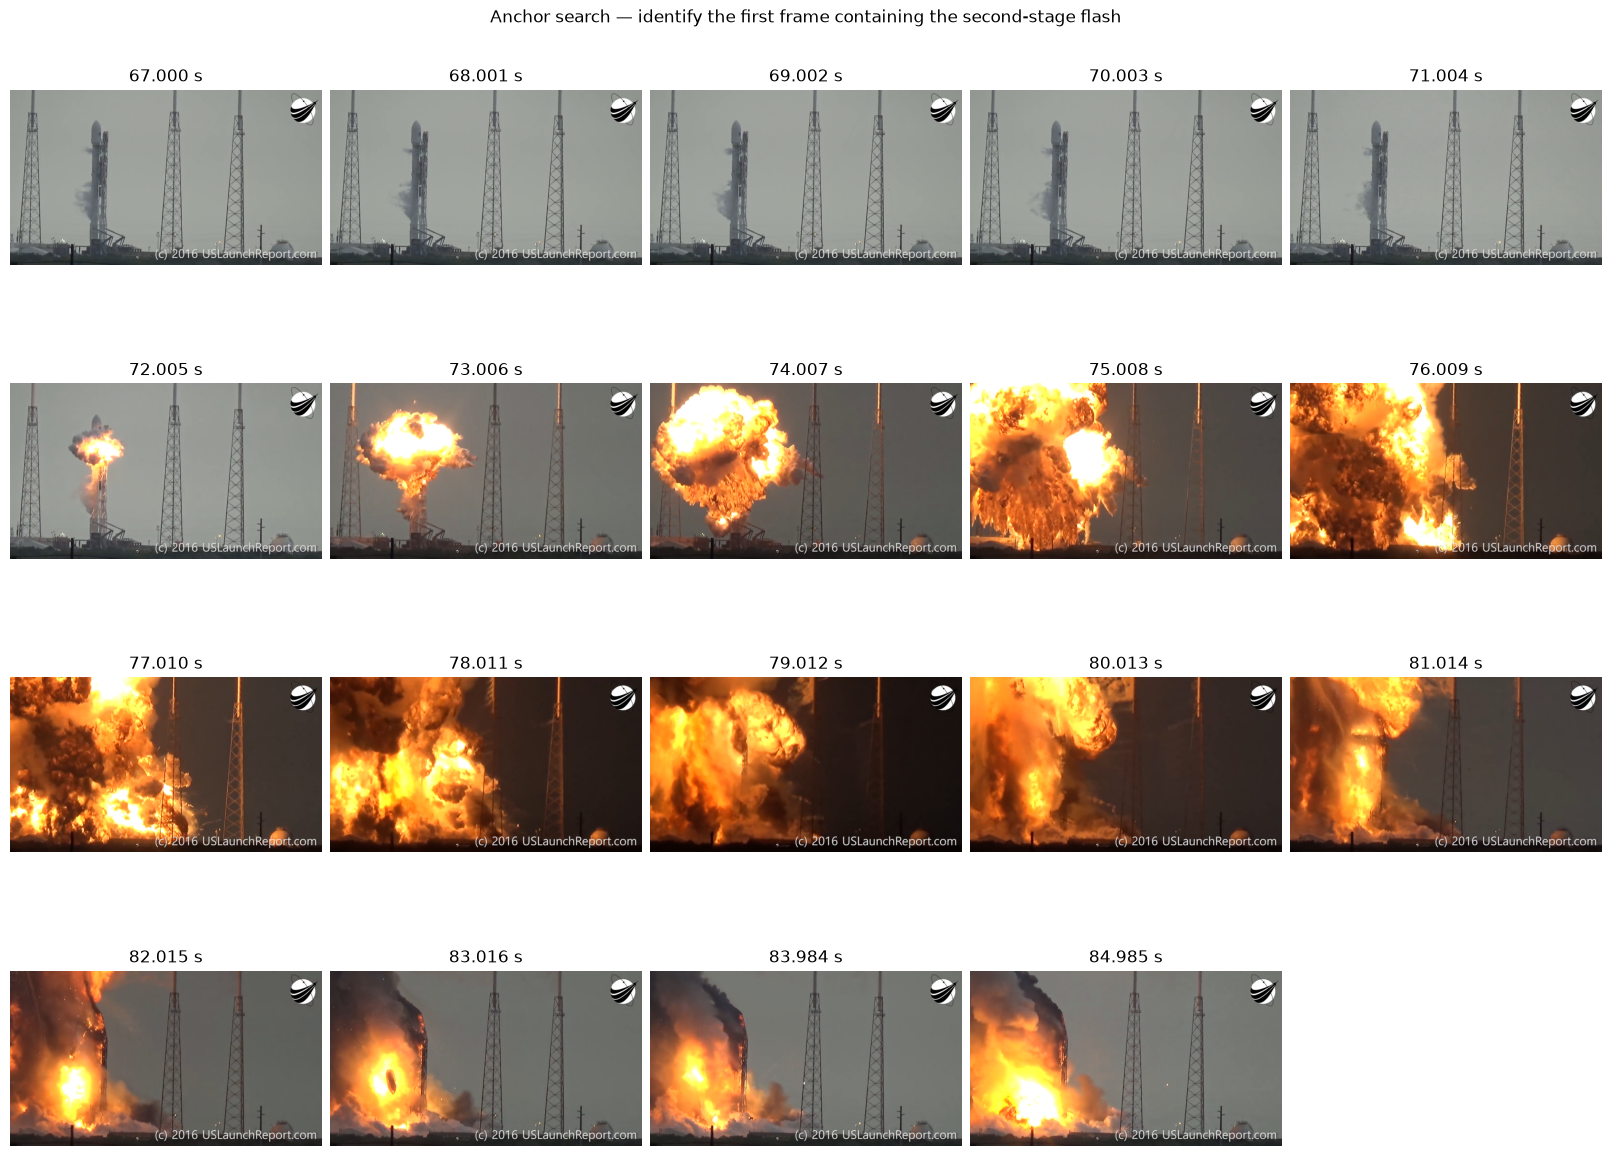

Set VIDEO_ANCHOR_S approximately to the first-flash neighborhood found above, rerun the configuration and video-reader cells, then run the fine preview below.


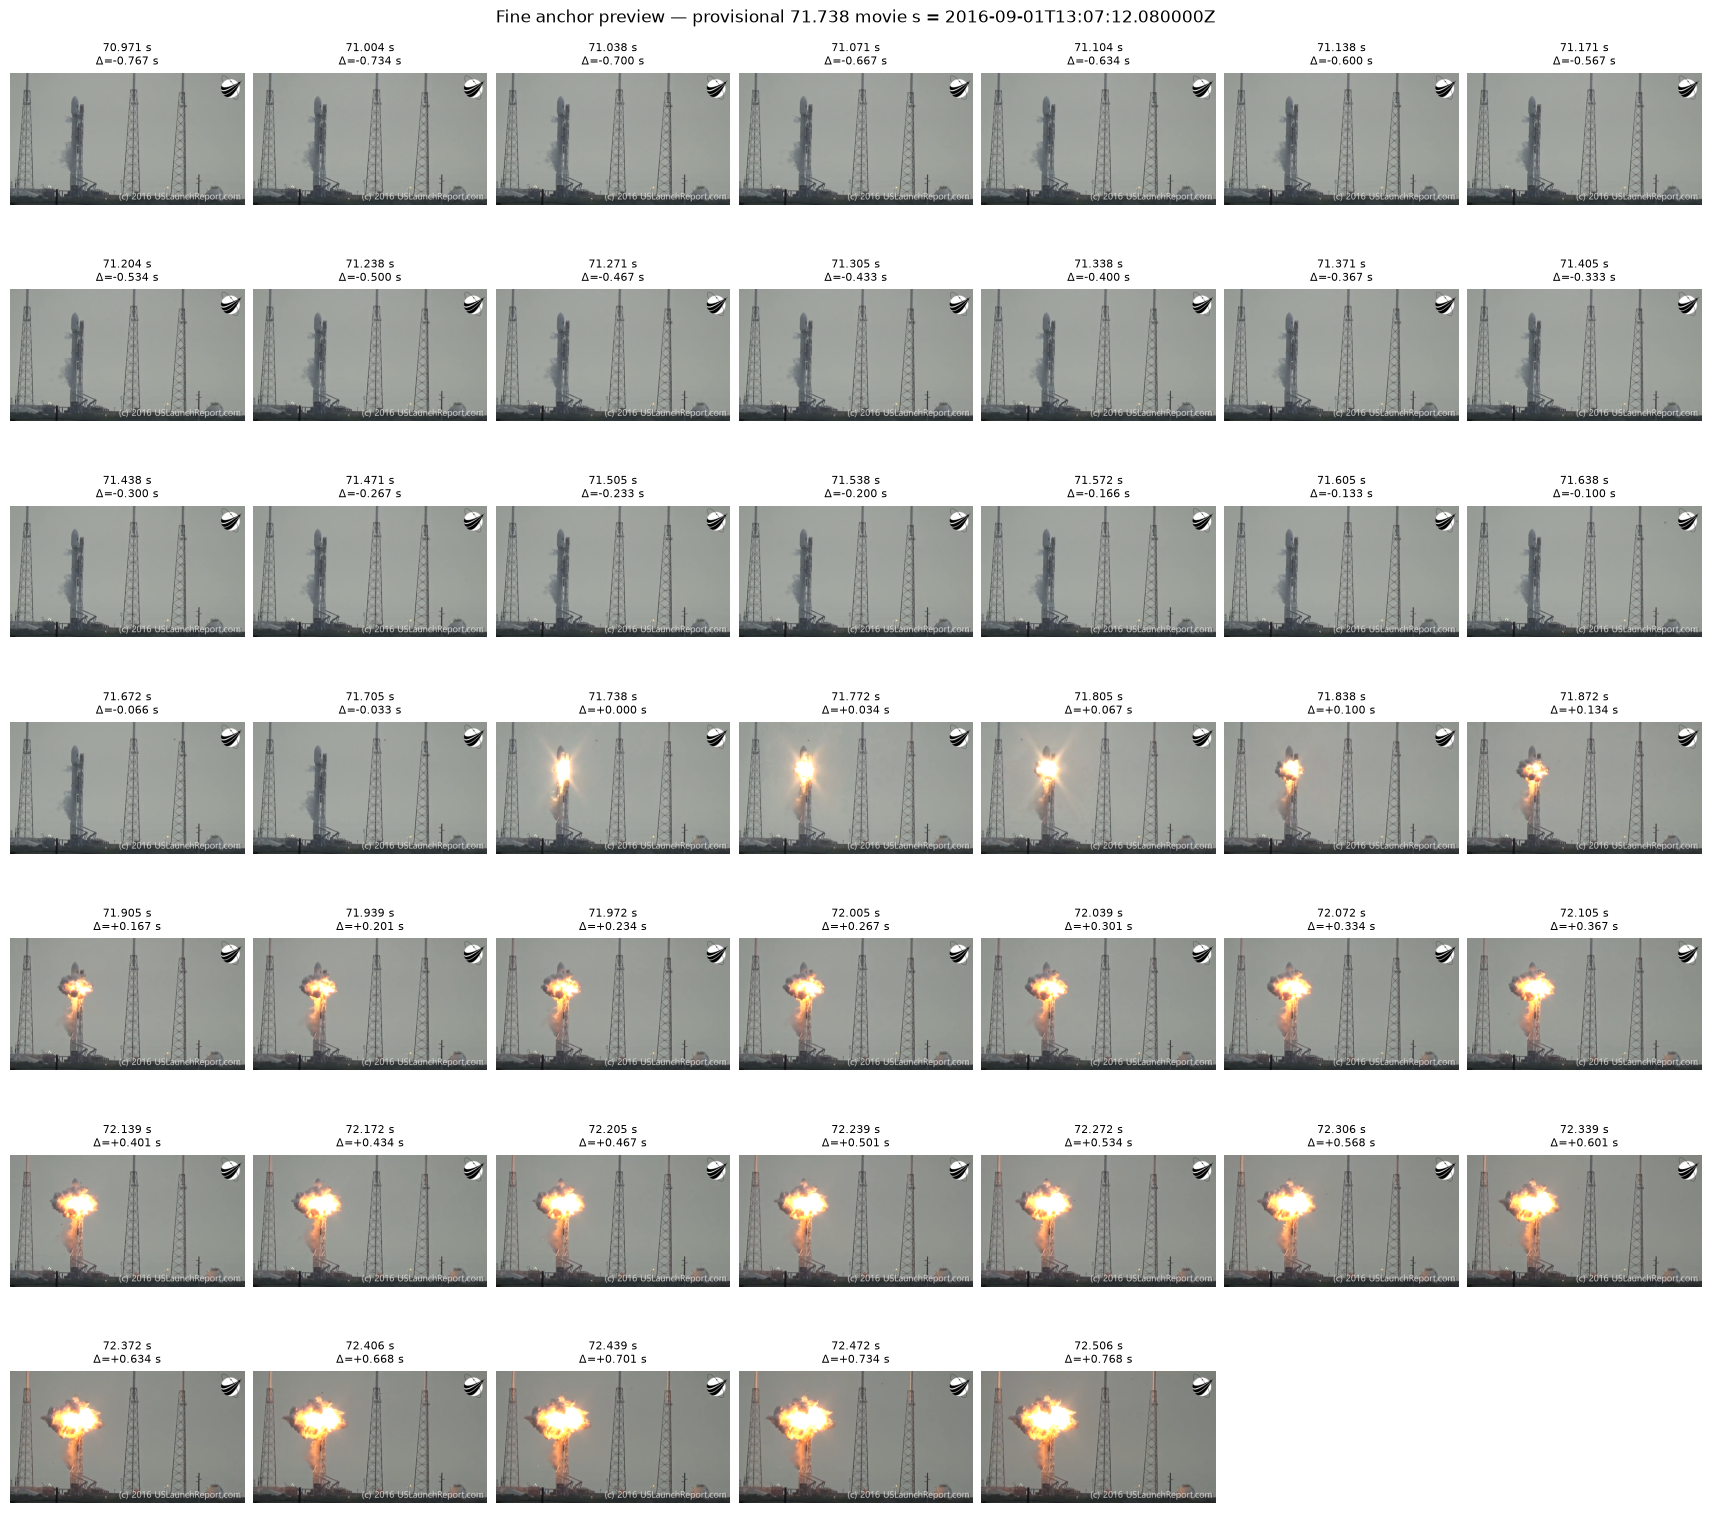

Anchor preview: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/13_video_sync_anchor_preview.png
Choose the FIRST frame showing the second-stage flash. Copy the movie timestamp printed above that frame into VIDEO_ANCHOR_S, set ANCHOR_IS_CONFIRMED=True, and rerun from the configuration cell.


In [17]:
# -------------------------------------------------------------------------
# Video-anchor calibration
# -------------------------------------------------------------------------
# Stage 1: one-second sampling over the explosion neighborhood established by
# the coarse whole-video contact sheet.
search_times_s = np.arange(
    ANCHOR_SEARCH_START_S,
    ANCHOR_SEARCH_END_S + 0.5 * ANCHOR_SEARCH_STEP_S,
    ANCHOR_SEARCH_STEP_S,
)

ncols = 5
nrows = int(np.ceil(len(search_times_s) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 3.0 * nrows),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, requested_s in zip(axes, search_times_s):
    frame, actual_s = video_reader.frame_at_video_seconds(float(requested_s))
    if frame is None:
        ax.text(0.5, 0.5, "No frame", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.imshow(frame)
    ax.set_axis_off()
    ax.set_title(f"{actual_s:.3f} s")

for ax in axes[len(search_times_s):]:
    ax.set_visible(False)

fig.suptitle(
    "Anchor search — identify the first frame containing the second-stage flash"
)
plt.show()

print(
    "Set VIDEO_ANCHOR_S approximately to the first-flash neighborhood found "
    "above, rerun the configuration and video-reader cells, then run the fine "
    "preview below."
)

# Stage 2: source-frame spacing around the configured anchor.
source_fps = (
    video_reader.nominal_fps
    if np.isfinite(video_reader.nominal_fps)
    else RENDER_FPS
)
fine_frame_count = int(np.ceil(FINE_ANCHOR_HALF_WIDTH_S * source_fps))
fine_offsets_s = (
    np.arange(-fine_frame_count, fine_frame_count + 1, dtype=float)
    / source_fps
)

ncols = 7
nrows = int(np.ceil(len(fine_offsets_s) / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(17, 2.2 * nrows),
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, offset_s in zip(axes, fine_offsets_s):
    requested_s = VIDEO_ANCHOR_S + float(offset_s)
    frame, actual_s = video_reader.frame_at_video_seconds(requested_s)
    if frame is None:
        ax.text(0.5, 0.5, "No frame", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.imshow(frame)
    ax.set_axis_off()
    ax.set_title(
        f"{actual_s:.3f} s\n"
        f"Δ={actual_s - VIDEO_ANCHOR_S:+.3f} s",
        fontsize=8,
    )

for ax in axes[len(fine_offsets_s):]:
    ax.set_visible(False)

fig.suptitle(
    f"Fine anchor preview — provisional {VIDEO_ANCHOR_S:.3f} movie s "
    f"= {VIDEO_ANCHOR_UTC}"
)
fig.savefig(CALIBRATION_FIGURE, dpi=140, bbox_inches="tight")
plt.show()

print("Anchor preview:", CALIBRATION_FIGURE)
print(
    "Choose the FIRST frame showing the second-stage flash. Copy the movie "
    "timestamp printed above that frame into VIDEO_ANCHOR_S, set "
    "ANCHOR_IS_CONFIRMED=True, and rerun from the configuration cell."
)


## 6. Rendering helpers


In [18]:
def plot_normalized_stream(ax, stream, reference_utc, scales, *, offsets=True):
    traces = list(stream)
    spacing = 2.2 if offsets else 0.0
    y_positions = {}
    for index, trace in enumerate(traces):
        times = relative_time(trace, reference_utc)
        values = np.asarray(trace.data, dtype=float) / scales[trace.id]
        offset = index * spacing
        ax.plot(times, values + offset, lw=0.65, label=trace.stats.channel)
        y_positions[trace.id] = offset
    if offsets:
        ax.set_yticks([index * spacing for index in range(len(traces))])
        ax.set_yticklabels([trace.stats.channel for trace in traces])
    return spacing, y_positions


def add_reference_markers(ax):
    """Add static event/source and approximate-arrival guides."""
    if not SHOW_STATIC_EVENT_MARKERS:
        return
    for label, delay_s in REFERENCE_MARKERS:
        if "source" in label.lower():
            color, linestyle, alpha = "tab:red", ":", 0.70
        elif "candidate p" in label.lower():
            color, linestyle, alpha = "tab:purple", "--", 0.55
        else:
            color, linestyle, alpha = "0.35", "--", 0.45
        ax.axvline(
            float(delay_s),
            color=color,
            ls=linestyle,
            lw=0.75,
            alpha=alpha,
            label=label,
            zorder=1,
        )


def add_current_video_utc_cursor(ax, elapsed_s: float):
    """Blue source-time cursor: actual UTC represented by the video frame."""
    if SHOW_CURRENT_VIDEO_UTC_CURSOR:
        ax.axvline(
            elapsed_s,
            color="tab:blue",
            lw=1.5,
            alpha=0.95,
            zorder=8,
        )


def add_dynamic_trace_arrivals(
    ax,
    stream,
    y_positions,
    elapsed_s: float,
    speed_mps: float,
    distances_m: dict[str, float],
    *,
    color: str,
    label: str,
    marker_half_height: float = 0.65,
):
    """
    Mark, on each trace, where a disturbance visible in the current video frame
    is predicted to arrive after propagation at `speed_mps`.
    """
    arrival_x = []
    for trace in stream:
        distance_m = float(distances_m[trace.id])
        x = elapsed_s + distance_m / float(speed_mps)
        y = float(y_positions[trace.id])
        ax.vlines(
            x,
            y - marker_half_height,
            y + marker_half_height,
            color=color,
            lw=2.0,
            alpha=0.95,
            zorder=9,
        )
        arrival_x.append(x)

    if arrival_x:
        # Dummy artist gives one clean legend entry instead of one per trace.
        ax.plot([], [], color=color, lw=2.0, label=label)
    return arrival_x


def render_sync_frame(render_utc: UTCDateTime, output_path: Path):
    elapsed_s = float(render_utc - VIDEO_ANCHOR_UTC)
    frame_rgb, actual_video_s = video_reader.frame_at_utc(render_utc)

    show_audio = (
        SHOW_VIDEO_AUDIO_PANEL
        and audio_time_s is not None
        and audio_values is not None
    )
    nrows = 6 if show_audio else 5
    height_ratios = (
        [3.2, 0.9, 1.35, 1.35, 1.35, 1.25]
        if show_audio
        else [3.2, 1.35, 1.35, 1.35, 1.25]
    )

    fig = plt.figure(figsize=(14, 11 if show_audio else 10))
    grid = GridSpec(nrows, 1, figure=fig, height_ratios=height_ratios)
    fig.subplots_adjust(
        left=0.08, right=0.98, bottom=0.055, top=0.94, hspace=0.42
    )

    row = 0
    ax_video = fig.add_subplot(grid[row, 0])
    row += 1
    if frame_rgb is None:
        ax_video.text(
            0.5, 0.5, "No video frame at this UTC time",
            ha="center", va="center", transform=ax_video.transAxes,
        )
    else:
        ax_video.imshow(frame_rgb)
    ax_video.set_axis_off()
    ax_video.set_title(
        "SpaceXStaticFireAnomalyAMOS_6_Youtube.mov — "
        f"video PTS {actual_video_s:.3f} s — "
        f"UTC {render_utc.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}"
    )

    if show_audio:
        ax_audio = fig.add_subplot(grid[row, 0])
        row += 1
        ax_audio.plot(audio_time_s, audio_values, color="black", lw=0.45)
        add_current_video_utc_cursor(ax_audio, elapsed_s)
        add_reference_markers(ax_audio)
        if AUDIO_PANEL_ZOOMED:
            ax_audio.set_xlim(
                elapsed_s - WAVEFORM_ZOOM_S / 2,
                elapsed_s + WAVEFORM_ZOOM_S / 2,
            )
        else:
            ax_audio.set_xlim(
                float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
                float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
            )
        ax_audio.set_ylim(-1.05, 1.05)
        ax_audio.set_ylabel("Video audio")
        ax_audio.grid(True, alpha=0.15)

    ax_infra = fig.add_subplot(grid[row, 0])
    row += 1
    _, infra_y = plot_normalized_stream(
        ax_infra, st_infrasound_plot, VIDEO_ANCHOR_UTC, infra_scales, offsets=True
    )
    add_current_video_utc_cursor(ax_infra, elapsed_s)
    add_reference_markers(ax_infra)

    if SHOW_DYNAMIC_INFRASOUND_ARRIVALS:
        # Array-wide band for the video-frame source time propagated through air.
        band_left = elapsed_s + infra_band_distance_min_m / SOUND_SPEED_MPS
        band_right = elapsed_s + infra_band_distance_max_m / SOUND_SPEED_MPS
        ax_infra.axvspan(
            band_left,
            band_right,
            color="tab:cyan",
            alpha=0.22,
            zorder=2,
            label="Current-frame acoustic arrival across array",
        )
        add_dynamic_trace_arrivals(
            ax_infra,
            st_infrasound_plot,
            infra_y,
            elapsed_s,
            SOUND_SPEED_MPS,
            infra_distances_m,
            color="tab:cyan",
            label="Per-channel acoustic arrival",
        )

    ax_infra.set_xlim(
        float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
        float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
    )
    ax_infra.set_ylabel("Infrasound\n(normalized)")
    ax_infra.grid(True, alpha=0.15)

    ax_seis_full = fig.add_subplot(grid[row, 0])
    row += 1
    _, seis_full_y = plot_normalized_stream(
        ax_seis_full, st_seismic_plot, VIDEO_ANCHOR_UTC, seismic_scales, offsets=True
    )
    add_current_video_utc_cursor(ax_seis_full, elapsed_s)
    add_reference_markers(ax_seis_full)
    if SHOW_DYNAMIC_P_ARRIVALS:
        add_dynamic_trace_arrivals(
            ax_seis_full,
            st_seismic_plot,
            seis_full_y,
            elapsed_s,
            P_WAVE_SPEED_MPS,
            seismic_distances_m,
            color="tab:purple",
            label="Current-frame predicted P arrival",
        )
    ax_seis_full.set_xlim(
        float(RENDER_START_UTC - VIDEO_ANCHOR_UTC),
        float(RENDER_END_UTC - VIDEO_ANCHOR_UTC),
    )
    ax_seis_full.set_ylabel("Z/R/T\n(normalized)")
    ax_seis_full.grid(True, alpha=0.15)

    ax_seis_zoom = fig.add_subplot(grid[row, 0])
    row += 1
    _, seis_zoom_y = plot_normalized_stream(
        ax_seis_zoom, st_seismic_plot, VIDEO_ANCHOR_UTC, seismic_scales, offsets=True
    )
    add_current_video_utc_cursor(ax_seis_zoom, elapsed_s)
    if SHOW_DYNAMIC_P_ARRIVALS:
        add_dynamic_trace_arrivals(
            ax_seis_zoom,
            st_seismic_plot,
            seis_zoom_y,
            elapsed_s,
            P_WAVE_SPEED_MPS,
            seismic_distances_m,
            color="tab:purple",
            label="Current-frame predicted P arrival",
        )
    ax_seis_zoom.set_xlim(
        elapsed_s - WAVEFORM_ZOOM_S / 2,
        elapsed_s + WAVEFORM_ZOOM_S / 2,
    )
    ax_seis_zoom.set_ylabel("Scrolling\nZ/R/T")
    ax_seis_zoom.grid(True, alpha=0.15)

    ax_pol = fig.add_subplot(grid[row, 0])
    pol_left = elapsed_s - WAVEFORM_ZOOM_S / 2
    pol_right = elapsed_s + WAVEFORM_ZOOM_S / 2
    pol_visible = polarization.loc[
        (polarization["elapsed_from_explosion_s"] >= pol_left - 1.0)
        & (polarization["elapsed_from_explosion_s"] <= pol_right + 1.0)
    ]
    plotted_pol_series = 0
    for column, label in POLARIZATION_ATTRIBUTES:
        if column not in pol_visible.columns:
            continue
        finite = np.isfinite(pol_visible[column].to_numpy(dtype=float))
        if not finite.any():
            continue
        ax_pol.plot(
            pol_visible.loc[finite, "elapsed_from_explosion_s"],
            pol_visible.loc[finite, column],
            lw=1.0,
            label=label,
        )
        plotted_pol_series += 1
    add_current_video_utc_cursor(ax_pol, elapsed_s)
    add_reference_markers(ax_pol)
    ax_pol.set_xlim(pol_left, pol_right)
    ax_pol.set_ylim(-0.05, 1.05)
    ax_pol.set_ylabel("Polarization")
    ax_pol.set_xlabel("Time relative to second-stage source time (s)")
    if plotted_pol_series:
        ax_pol.legend(loc="upper right", ncol=min(5, plotted_pol_series), fontsize=7)
    else:
        ax_pol.text(
            0.5, 0.5,
            "No finite polarization values in this window",
            ha="center", va="center", transform=ax_pol.transAxes,
        )
    ax_pol.grid(True, alpha=0.15)

    # Keep legends compact; the video UTC itself is also printed in the title.
    for ax in [ax_infra, ax_seis_full, ax_seis_zoom]:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            # Deduplicate repeated labels.
            dedup = dict(zip(labels, handles))
            ax.legend(
                dedup.values(),
                dedup.keys(),
                loc="upper right",
                fontsize=6,
                ncol=min(4, len(dedup)),
            )

    fig.suptitle(
        "Falcon 9 AMOS-6 anomaly — "
        f"current video UTC {render_utc.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]}"
    )
    fig.savefig(output_path, dpi=FIGURE_DPI, facecolor="white")
    plt.close(fig)


## 7. Render synchronized PNG frames


In [19]:
'''if RENDER_PNG_FRAMES and not ANCHOR_IS_CONFIRMED:
    raise RuntimeError(
        "Refusing to render a production movie with an unconfirmed video anchor. "
        "Use the contact sheet, set VIDEO_ANCHOR_S, then set ANCHOR_IS_CONFIRMED=True."
    )

if DELETE_EXISTING_FRAMES and FRAME_DIR.exists():
    for existing in FRAME_DIR.glob("frame_*.png"):
        existing.unlink()

render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
number_of_frames = int(np.floor(render_duration_s * RENDER_FPS)) + 1
if MAX_FRAMES is not None:
    number_of_frames = min(number_of_frames, int(MAX_FRAMES))

if RENDER_PNG_FRAMES:
    for frame_number in range(number_of_frames):
        render_utc = RENDER_START_UTC + frame_number / RENDER_FPS
        output_path = FRAME_DIR / f"frame_{frame_number:06d}.png"
        render_sync_frame(render_utc, output_path)

        if frame_number == 0 or (frame_number + 1) % 50 == 0 or frame_number + 1 == number_of_frames:
            print(f"Rendered {frame_number + 1}/{number_of_frames}: {output_path.name}")
else:
    print("RENDER_PNG_FRAMES is False; no production frames rendered.")

rendered_frames = sorted(FRAME_DIR.glob("frame_*.png"))
print("Frames present:", len(rendered_frames))
'''


'if RENDER_PNG_FRAMES and not ANCHOR_IS_CONFIRMED:\n    raise RuntimeError(\n        "Refusing to render a production movie with an unconfirmed video anchor. "\n        "Use the contact sheet, set VIDEO_ANCHOR_S, then set ANCHOR_IS_CONFIRMED=True."\n    )\n\nif DELETE_EXISTING_FRAMES and FRAME_DIR.exists():\n    for existing in FRAME_DIR.glob("frame_*.png"):\n        existing.unlink()\n\nrender_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)\nnumber_of_frames = int(np.floor(render_duration_s * RENDER_FPS)) + 1\nif MAX_FRAMES is not None:\n    number_of_frames = min(number_of_frames, int(MAX_FRAMES))\n\nif RENDER_PNG_FRAMES:\n    for frame_number in range(number_of_frames):\n        render_utc = RENDER_START_UTC + frame_number / RENDER_FPS\n        output_path = FRAME_DIR / f"frame_{frame_number:06d}.png"\n        render_sync_frame(render_utc, output_path)\n\n        if frame_number == 0 or (frame_number + 1) % 50 == 0 or frame_number + 1 == number_of_frames:\n            print(f"

In [20]:
import time

render_duration_s = float(RENDER_END_UTC - RENDER_START_UTC)
number_of_frames = int(np.floor(render_duration_s * RENDER_FPS)) + 1

if MAX_FRAMES is not None:
    number_of_frames = min(number_of_frames, int(MAX_FRAMES))

existing_frame_numbers = {
    int(path.stem.split("_")[-1])
    for path in FRAME_DIR.glob("frame_*.png")
}

print(
    f"Requested frames: {number_of_frames}; "
    f"already present: {len(existing_frame_numbers)}"
)

render_start_clock = time.perf_counter()
frames_rendered_this_run = 0

if RENDER_PNG_FRAMES:
    for frame_number in range(number_of_frames):
        output_path = FRAME_DIR / f"frame_{frame_number:06d}.png"

        # Resume without regenerating completed frames.
        if (
            frame_number in existing_frame_numbers
            and output_path.exists()
            and output_path.stat().st_size > 0
        ):
            continue

        render_utc = RENDER_START_UTC + frame_number / RENDER_FPS

        frame_clock = time.perf_counter()
        render_sync_frame(render_utc, output_path)
        frame_seconds = time.perf_counter() - frame_clock

        frames_rendered_this_run += 1

        if (
            frames_rendered_this_run == 1
            or frames_rendered_this_run % 10 == 0
            or frame_number + 1 == number_of_frames
        ):
            elapsed = time.perf_counter() - render_start_clock
            mean_seconds = elapsed / frames_rendered_this_run

            remaining_frames = number_of_frames - frame_number - 1
            estimated_remaining_minutes = (
                remaining_frames * mean_seconds / 60.0
            )

            print(
                f"Rendered {frame_number + 1}/{number_of_frames}: "
                f"{output_path.name}; "
                f"this frame={frame_seconds:.2f} s; "
                f"mean={mean_seconds:.2f} s/frame; "
                f"estimated remaining={estimated_remaining_minutes:.1f} min",
                flush=True,
            )
else:
    print("RENDER_PNG_FRAMES is False; no production frames rendered.")

rendered_frames = sorted(FRAME_DIR.glob("frame_*.png"))
print("Frames present:", len(rendered_frames))

Requested frames: 615; already present: 615
Frames present: 615


## 8. Assemble the MP4 with ffmpeg


In [21]:
# Assembly is performed in the next cell, which handles even dimensions\n# and optionally muxes the source MOV audio in native video timing.\nprint("Proceed to the robust assembly cell below.")\n

In [22]:
# Obsolete assembly implementation retained as a no-op.
# Use the next cell, which muxes the already-extracted authoritative WAV clip.
print("Skipping obsolete assembly cell; run the next cell.")

Skipping obsolete assembly cell; run the next cell.


In [23]:
import subprocess
from PIL import Image

rendered_frames = sorted(FRAME_DIR.glob("frame_*.png"))
if not rendered_frames:
    raise FileNotFoundError(f"No PNG frames found in {FRAME_DIR}")

expected_names = [
    FRAME_DIR / f"frame_{index:06d}.png"
    for index in range(EXPECTED_FRAME_COUNT)
]
missing_frames = [path for path in expected_names if not path.exists()]
if missing_frames:
    raise RuntimeError(
        f"Cannot assemble movie: {len(missing_frames)} expected PNG frames "
        f"are missing. First missing: {missing_frames[0]}"
    )

with Image.open(rendered_frames[0]) as image:
    frame_width, frame_height = image.size

print(
    f"Found {len(rendered_frames)} frames; "
    f"frame dimensions={frame_width} × {frame_height}"
)
print(
    "PNG frame 000000 source PTS:",
    f"{FIRST_RENDERED_VIDEO_PTS_S:.6f} s",
)

ffmpeg_path = shutil.which("ffmpeg")
if ASSEMBLE_MP4:
    if ffmpeg_path is None:
        raise FileNotFoundError("ffmpeg was not found on PATH.")

    use_source_audio = (
        INCLUDE_VIDEO_AUDIO_IN_MP4
        and video_reader.has_audio
        and EXTRACTED_AUDIO_WAV.exists()
        and EXTRACTED_AUDIO_WAV.stat().st_size > 0
    )

    command = [
        ffmpeg_path,
        "-y",
        "-framerate", f"{RENDER_FPS:.8f}",
        "-i", str(FRAME_DIR / "frame_%06d.png"),
    ]

    if use_source_audio:
        # This WAV was clipped once using the actual PTS of PNG frame 000000.
        # It already starts at zero, so no second seek/trim is allowed here.
        command += [
            "-i", str(EXTRACTED_AUDIO_WAV),
        ]

    command += [
        "-map", "0:v:0",
    ]
    if use_source_audio:
        command += ["-map", "1:a:0"]

    command += [
        "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
        "-c:v", "libx264",
        "-preset", "medium",
        "-crf", "18",
        "-pix_fmt", "yuv420p",
        "-r", f"{RENDER_FPS:.8f}",
    ]

    if use_source_audio:
        command += [
            "-c:a", "aac",
            "-b:a", "192k",
        ]

    command += [
        "-t", f"{PNG_SEQUENCE_DURATION_S:.9f}",
        "-movflags", "+faststart",
        str(OUTPUT_MOVIE),
    ]

    print("Running:")
    print(" ".join(command))

    result = subprocess.run(
        command,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    if result.returncode != 0:
        diagnostic_tail = "\n".join(result.stderr.splitlines()[-60:])
        raise RuntimeError(
            f"FFmpeg failed with return code {result.returncode}.\n\n"
            f"{diagnostic_tail}"
        )

    if not OUTPUT_MOVIE.exists() or OUTPUT_MOVIE.stat().st_size < 100_000:
        diagnostic_tail = "\n".join(result.stderr.splitlines()[-60:])
        output_bytes = (
            OUTPUT_MOVIE.stat().st_size if OUTPUT_MOVIE.exists() else 0
        )
        raise RuntimeError(
            f"Output movie is missing or unexpectedly small "
            f"({output_bytes:,} bytes).\n\n"
            f"{diagnostic_tail}"
        )

    print(f"Created: {OUTPUT_MOVIE}")
    print(
        f"Size: {OUTPUT_MOVIE.stat().st_size / 1024**2:.3f} MB "
        f"({OUTPUT_MOVIE.stat().st_size:,} bytes)"
    )
    print("Source audio included:", use_source_audio)
    if use_source_audio:
        print(
            "Audio origin equals PNG frame 000000 source PTS:",
            f"{FIRST_RENDERED_VIDEO_PTS_S:.6f} s",
        )
else:
    print("ASSEMBLE_MP4 is False; PNG frames retained without movie assembly.")

Found 615 frames; frame dimensions=1400 × 1100
PNG frame 000000 source PTS: 69.736333 s
Running:
/Users/thompsong/miniforge3/envs/flovopy_asl/bin/ffmpeg -y -framerate 29.97002997 -i /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/frames_phase1/frame_%06d.png -i /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_audio_render_interval.wav -map 0:v:0 -map 1:a:0 -vf pad=ceil(iw/2)*2:ceil(ih/2)*2 -c:v libx264 -preset medium -crf 18 -pix_fmt yuv420p -r 29.97002997 -c:a aac -b:a 192k -t 20.520500000 -movflags +faststart /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_waveform_polarization_sync.mp4
Created: /User

## 9. Save synchronization provenance and close the video


In [24]:
sync_configuration = {
    "producer_notebook": "13_make_synchronized_video_phase1.ipynb",
    "video_file": str(VIDEO_FILE),
    "video_anchor_s": VIDEO_ANCHOR_S,
    "video_anchor_utc": str(VIDEO_ANCHOR_UTC),
    "derived_video_start_utc": str(video_start_utc),
    "video_nominal_fps": video_reader.nominal_fps,
    "video_duration_s": video_reader.duration_s,
    "video_has_audio": video_reader.has_audio,
    "render_start_utc": str(RENDER_START_UTC),
    "render_end_utc": str(RENDER_END_UTC),
    "render_start_video_s_requested": render_start_video_s,
    "first_rendered_video_pts_s": FIRST_RENDERED_VIDEO_PTS_S,
    "video_start_quantization_offset_s": VIDEO_START_QUANTIZATION_OFFSET_S,
    "png_sequence_duration_s": PNG_SEQUENCE_DURATION_S,
    "render_fps": RENDER_FPS,
    "waveform_zoom_s": WAVEFORM_ZOOM_S,
    "source_waveform_stream": str(BASELINE_STREAM_FILE),
    "source_rotated_zrt_stream": str(ROTATED_ZRT_PICKLE),
    "source_polarization_csv": str(POLARIZATION_CSV),
    "seismic_filter_hz": list(SEISMIC_FILTER_HZ),
    "infrasound_filter_hz": list(INFRASOUND_FILTER_HZ),
    "sound_speed_mps": SOUND_SPEED_MPS,
    "sound_speed_summary_csv": str(ARRAY_SOLUTION_SUMMARY_CSV),
    "sound_speed_summary_subset": SOUND_SPEED_SUMMARY_SUBSET,
    "sound_speed_statistic": SOUND_SPEED_STATISTIC,
    "sound_speed_value_column": SOUND_SPEED_VALUE_COLUMN,
    "p_wave_speed_mps": P_WAVE_SPEED_MPS,
    "infrasound_reference_delay_s": infra_reference_delay_s,
    "infrasound_array_delay_min_s": infra_band_delay_min_s,
    "infrasound_array_delay_max_s": infra_band_delay_max_s,
    "infrasound_array_delay_spread_s": infra_delay_spread_s,
    "seismic_reference_distance_m": seismic_reference_distance_m,
    "p_reference_delay_s": p_reference_delay_s,
    "infrasound_trace_distances_m": infra_distances_m,
    "seismic_trace_distances_m": seismic_distances_m,
    "trace_geometry": trace_geometry.to_dict(orient="records"),
    "include_source_audio_in_mp4": INCLUDE_VIDEO_AUDIO_IN_MP4,
    "show_video_audio_panel": SHOW_VIDEO_AUDIO_PANEL,
    "extracted_audio_wav": str(EXTRACTED_AUDIO_WAV),
    "reference_markers": [
        {"label": label, "delay_from_second_stage_s": delay_s}
        for label, delay_s in REFERENCE_MARKERS
    ],
    "frame_directory": str(FRAME_DIR),
    "output_movie": str(OUTPUT_MOVIE),
    "rendered_frame_count": len(rendered_frames),
}
SYNC_CONFIG_JSON.write_text(json.dumps(sync_configuration, indent=2) + "\n")
video_reader.close()

print("Synchronization configuration:", SYNC_CONFIG_JSON)
print("Anchor preview:", CALIBRATION_FIGURE)
print("Frames:", FRAME_DIR)
print("Movie:", OUTPUT_MOVIE)


Synchronization configuration: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_video_sync_configuration.json
Anchor preview: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/13_video_sync_anchor_preview.png
Frames: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/frames_phase1
Movie: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/13_synchronized_video/13_youtube_waveform_polarization_sync.mp4
